# Task 5 — Strategy Backtesting

**Objective:** Simulate the Task 4 optimal portfolio's performance over the last year
of historical data (January 2025 – January 2026) and compare it against a simple
static 60% SPY / 40% BND benchmark, to validate whether the model-driven approach
would have actually outperformed a passive strategy.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data_loader import fetch_stock_data, extract_close_prices, clean_data

print("All imports loaded successfully.")

All imports loaded successfully.


## 1. Load Data and Define the Backtesting Period

In [2]:
tickers = ["TSLA", "BND", "SPY"]
raw_data = fetch_stock_data(tickers, start_date="2015-01-01", end_date="2026-06-30")
close_prices = extract_close_prices(raw_data, tickers)
close_prices = clean_data(close_prices)

backtest_start = "2025-01-01"
backtest_end = "2026-01-31"
backtest_prices = close_prices[(close_prices.index >= backtest_start) & (close_prices.index <= backtest_end)]

print(f"Backtest period: {backtest_prices.index.min().date()} to {backtest_prices.index.max().date()}")
print(f"Number of trading days: {len(backtest_prices)}")
backtest_prices.head()

[*********************100%***********************]  3 of 3 completed

[INFO] Downloaded data shape: (2888, 15)
[INFO] Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
[INFO] Missing values — before: 0, after: 0
Backtest period: 2025-01-02 to 2026-01-30
Number of trading days: 270


Ticker,TSLA,BND,SPY
Date,,,
2025-01-02,379.279999,68.076210,574.799500
2025-01-03,410.440002,67.991043,581.986450
2025-01-06,411.049988,67.924812,585.339050
2025-01-07,394.359985,67.688217,578.722351
2025-01-08,394.940002,67.763947,579.567871


## 2. Calculate Daily Returns for the Backtest Window

In [3]:
backtest_returns = backtest_prices.pct_change().dropna()

print(f"Backtest returns shape: {backtest_returns.shape}")
backtest_returns.describe()

Backtest returns shape: (269, 3)


Ticker,TSLA,BND,SPY
count,269.000000,269.000000,269.000000
mean,0.001221,0.000265,0.000741
std,0.038949,0.002739,0.011955
min,-0.154262,-0.012056,-0.058543
25%,-0.021034,-0.001478,-0.003223
50%,-0.000070,0.000275,0.001376
75%,0.023849,0.001936,0.005729
max,0.226900,0.008662,0.105019


## 3. Define the Two Portfolios: Strategy vs. Benchmark

In [4]:
strategy_weights = {
  "TSLA": 0.27859,
  "BND": 0.0,
  "SPY": 0.72141
}

# ── Benchmark: static 60% SPY / 40% BND, no TSLA ──
benchmark_weights = {
  "TSLA": 0.0,
  "BND": 0.40,
  "SPY": 0.60
}

print("STRATEGY PORTFOLIO WEIGHTS (from Task 4)")
for asset, w in strategy_weights.items():
  print(f"  {asset}: {w*100:.2f}%")

print("\nBENCHMARK PORTFOLIO WEIGHTS")
for asset, w in benchmark_weights.items():
  print(f"  {asset}: {w*100:.2f}%")

STRATEGY PORTFOLIO WEIGHTS (from Task 4)
  TSLA: 27.86%
  BND: 0.00%
  SPY: 72.14%

BENCHMARK PORTFOLIO WEIGHTS
  TSLA: 0.00%
  BND: 40.00%
  SPY: 60.00%


## 4. Simulate Portfolio Performance (Buy-and-Hold)

In [5]:
def simulate_buy_and_hold(returns_df, weights_dict):
    """
    Simulate a portfolio that holds fixed initial weights for the entire period
    (no rebalancing). Returns the daily portfolio return series.
    """
    weights_series = pd.Series(weights_dict)
    
    portfolio_daily_returns = returns_df[weights_series.index].dot(weights_series)
    return portfolio_daily_returns


strategy_daily_returns = simulate_buy_and_hold(backtest_returns, strategy_weights)
benchmark_daily_returns = simulate_buy_and_hold(backtest_returns, benchmark_weights)

strategy_cumulative = (1 + strategy_daily_returns).cumprod()
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod()

print(f"Strategy final value of $1 invested:  ${strategy_cumulative.iloc[-1]:.4f}")
print(f"Benchmark final value of $1 invested: ${benchmark_cumulative.iloc[-1]:.4f}")

Strategy final value of $1 invested:  $1.2127
Benchmark final value of $1 invested: $1.1511


## 5. Visualize Cumulative Returns

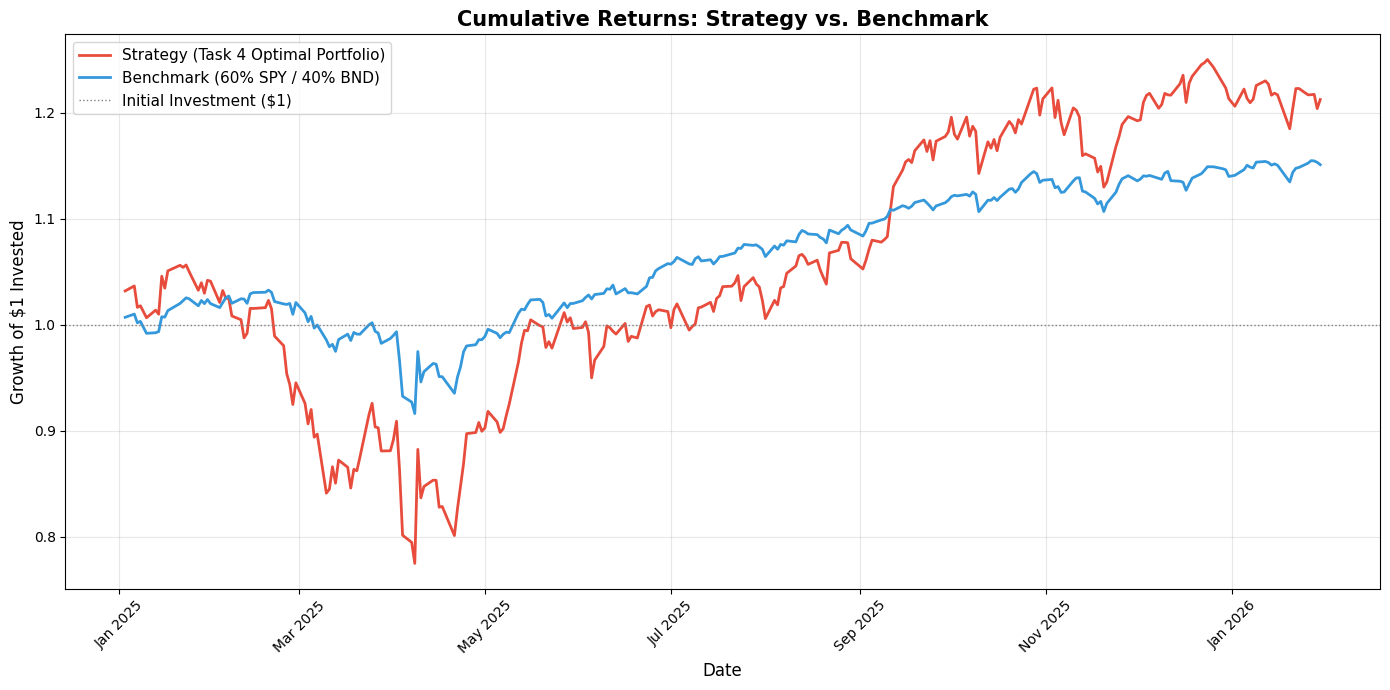

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(strategy_cumulative.index, strategy_cumulative.values,
        color="#e74c3c", linewidth=2, label="Strategy (Task 4 Optimal Portfolio)")
ax.plot(benchmark_cumulative.index, benchmark_cumulative.values,
        color="#3498db", linewidth=2, label="Benchmark (60% SPY / 40% BND)")

ax.axhline(y=1.0, color="gray", linestyle=":", linewidth=1, label="Initial Investment ($1)")

ax.set_title("Cumulative Returns: Strategy vs. Benchmark", fontsize=15, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Growth of $1 Invested", fontsize=12)
ax.legend(loc="best", fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plots/task5_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Calculate Performance Metrics

In [7]:
def calculate_backtest_metrics(daily_returns, cumulative_returns, name="Portfolio"):
    """
    Calculate total return, annualized return, Sharpe Ratio, and max drawdown
    for a backtested portfolio.
    """
    total_return = cumulative_returns.iloc[-1] - 1
    n_days = len(daily_returns)
    annualized_return = (1 + total_return) ** (252 / n_days) - 1

    risk_free_rate = 0.02
    annualized_volatility = daily_returns.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

    # Maximum drawdown: largest peak-to-trough decline
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()

    print(f"--- {name} ---")
    print(f"  Total Return:        {total_return*100:.2f}%")
    print(f"  Annualized Return:   {annualized_return*100:.2f}%")
    print(f"  Sharpe Ratio:        {sharpe_ratio:.4f}")
    print(f"  Maximum Drawdown:    {max_drawdown*100:.2f}%")
    print()

    return {
        "Portfolio": name,
        "Total Return (%)": round(total_return*100, 2),
        "Annualized Return (%)": round(annualized_return*100, 2),
        "Sharpe Ratio": round(sharpe_ratio, 4),
        "Max Drawdown (%)": round(max_drawdown*100, 2)
    }

strategy_metrics = calculate_backtest_metrics(strategy_daily_returns, strategy_cumulative, "Strategy Portfolio")
benchmark_metrics = calculate_backtest_metrics(benchmark_daily_returns, benchmark_cumulative, "Benchmark Portfolio")

metrics_comparison = pd.DataFrame([strategy_metrics, benchmark_metrics]).set_index("Portfolio")
metrics_comparison

--- Strategy Portfolio ---
  Total Return:        21.27%
  Annualized Return:   19.80%
  Sharpe Ratio:        0.6272
  Maximum Drawdown:    -26.67%

--- Benchmark Portfolio ---
  Total Return:        15.11%
  Annualized Return:   14.10%
  Sharpe Ratio:        1.0346
  Maximum Drawdown:    -11.29%



,Total Return (%),Annualized Return (%),Sharpe Ratio,Max Drawdown (%)
Portfolio,,,,
Strategy Portfolio,21.27,19.8,0.6272,-26.67
Benchmark Portfolio,15.11,14.1,1.0346,-11.29


## 7. Conclusion and Reflection

### Did the Strategy Outperform the Benchmark?

Over the backtesting period (2025-01-01 to 2026-01-31), the Strategy Portfolio delivered a total return of **21.27%** (annualized: **19.80%**), with a Sharpe Ratio of **0.6272** and a maximum drawdown of **26.67%**. The Benchmark (60% SPY / 40% BND) delivered a total return of **15.11%** (annualized: **14.10%**), with a Sharpe Ratio of **1.0346** and a maximum drawdown of **11.29%**.

Summary: the Strategy outperformed the benchmark on total return but underperformed on a risk-adjusted basis (Sharpe) and suffered materially larger drawdowns. In practice this means the model-driven allocation added return but concentrated downside risk (largely due to TSLA exposure driven by the Task 3 forecast).

Recommendations:

- For clients focused on risk-adjusted performance or capital preservation, prefer the benchmark or reduce the TSLA exposure (trim concentration).  
- For clients with higher return tolerance, the Strategy may be acceptable but should include explicit risk controls: position size limits, monthly rebalancing, volatility-based caps, or stop-loss rules.  
- Treat the TSLA-driven allocation as a view-based tilt, not a permanent allocation — revisit weights as new forecasts arrive.

Validation & next steps (required before productionizing):

- Run multi-period / rolling-window backtests and bootstrap simulations to test robustness across different market regimes.  
- Add transaction costs, slippage, and realistic rebalancing (monthly) to the simulation.  
- Perform sensitivity checks: shrink Task 3 expected return toward the historical mean, and test how the portfolio changes.  
- Consider ensemble forecasts or down-weighting single-asset forecast-driven allocations to reduce concentration risk.

This notebook provides a single-year, illustrative backtest. Use the above validations before treating these results as a deployment signal.

In [8]:
metrics_comparison.to_csv("../data/task5_backtest_metrics.csv")
print("Backtest metrics saved to data/task5_backtest_metrics.csv")

print("\n" + "=" * 60)
print("         TASK 5 COMPLETE — DELIVERABLES")
print("=" * 60)
print("  Cumulative returns plot:   plots/task5_cumulative_returns.png")
print("  Performance metrics:       data/task5_backtest_metrics.csv")
print("  Conclusion & reflection:   Written in Section 7 above")
print("=" * 60)
print("\n  ALL 5 TASKS COMPLETE — PROJECT FINISHED! ")


Backtest metrics saved to data/task5_backtest_metrics.csv

         TASK 5 COMPLETE — DELIVERABLES
  Cumulative returns plot:   plots/task5_cumulative_returns.png
  Performance metrics:       data/task5_backtest_metrics.csv
  Conclusion & reflection:   Written in Section 7 above

  ALL 5 TASKS COMPLETE — PROJECT FINISHED! 
